<div align="center">

#### Inteligencja obliczeniowa w analizie danych | Inżynieria i Analiza Danych
# Projekt Fuzzy Logic
### Mateusz Bugdol  
### Nr indeksu: 419719  
### Grupa ćwiczeniowa: 1 
 
</div>

1. Cel projektu

Celem projektu jest zaprojektowanie i implementacja systemu wnioskowania rozmytego (Fuzzy Logic) do przewidywania wyników meczów piłki nożnej. System ma za zadanie ocenić prawdopodobieństwo wygranej danej drużyny na podstawie jej statystyk historycznych, a następnie porównać skuteczność tych predykcji z kursami oferowanymi przez rynki bukmacherskie. Projekt ma zweryfikować, w jakim stopniu logika rozmyta pozwala zamodelować nieliniową naturę wyników sportowych.

2. Opis zadania

Zadanie polega na analizie danych historycznych ze spotkań piłkarskich Premier League z sezonu 2024/2025 i ekstrakcji wiedzy pozwalającej na ocenę siły zespołów. Następnie konieczne jest stworzenie systemu opartego o logikę rozmytą, składającego się z odpowiednio dobranych zmiennych wejściowych, funkcji przynależności oraz bazy reguł. Wyjściem systemu będzie estymowana szansa na zwycięstwo wyrażona w procentach. Finalnym krokiem jest ewaluacja skuteczności (accuracy) modelu względem poprawnych prognoz bukmacherów w celu weryfikacji jego użyteczności.

3. Implementacja Fuzzy Logic

W tej sekcji zaprezentowano proces budowy modelu od przygotowania danych, poprzez tworzenie cech, aż po definicję logiki rozmytej i jej symulację.

3.1. Załadowanie bibliotek

Zaimportowano podstawowe narzędzia do manipulacji danymi i wizualizacji (`pandas`, `numpy`, `matplotlib`, `seaborn`) oraz bibliotekę `scikit-fuzzy` wraz z jej modułem `control` służącym do bezpośredniego projektowania systemów rozmytych.

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np

3.2. Wczytanie danych

Dane źródłowe pobierane są z pliku `pl_data.csv` pochodzącego ze strony [football-data.co.uk](https://www.football-data.co.uk/). Zbiór jest wstępnie filtrowany w celu pozostawienia wyłącznie najistotniejszych kolumn, takich jak zespoły, data, wynik końcowy, strzały celne, gole oraz kursy bukmacherskie. Przeprowadzono również standaryzację formatu daty oraz przetłumaczono nazwy kolumn na język polski w celu zwiększenia czytelności.

In [44]:
df = pd.read_csv('pl_data.csv')
df = df[['Date', 'HomeTeam', 'AwayTeam', 'FTR', 'HST', 'AST', 'FTHG', 'FTAG', 'AvgH', 'AvgA']]
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df.columns = ['Data', 'Gospodarz', 'Gość', 'Wynik', 'Strzały celne gospodarza', 'Strzały celne gościa', 'Gole gospodarza', 'Gole gościa', 'Średnia kursu gospodarza', 'Średnia kursu gościa']

3.3 Feature Engineering

Z surowych statystyk utworzono zmienne ustandaryzowane do przedziału $[-1, 1]$, które posłużyły do testowania modelu:

* **Forma relatywna:** Momentum bazujące na punktach z 5 ostatnich meczów.
  *Wzór:* `(Punkty drużyny - Punkty przeciwnika) / 15`
* **Forma HA relatywna (Home/Away):** Forma z uwzględnieniem atutu boiska (mecze domowe dla gospodarza, wyjazdowe dla gościa).
  *Wzór:* `(PunktyHA drużyny - PunktyHA przeciwnika) / 15`
* **SOT relatywny:** Dominacja w strzałach celnych.
  *Wskaźnik =* `SOT zdobyte / (SOT zdobyte + SOT dopuszczone)`
  *Wzór:* `Wskaźnik drużyny - Wskaźnik przeciwnika`
* **Gole relatywne:** Skuteczność bramkowa liczona analogicznie do SOT.
  *Wskaźnik =* `Gole zdobyte / (Gole zdobyte + Gole stracone)`
  *Wzór:* `Wskaźnik drużyny - Wskaźnik przeciwnika`
* **Pozycja relatywna:** Różnica miejsc w tabeli ligowej.
  *Wzór:* `(Pozycja przeciwnika - Pozycja drużyny) / (Liczba drużyn - 1)`
* **Kursy relatywne:** Różnica prawdopodobieństw z kursów bukmacherskich.
  *Wzór:* `(1 / Kurs drużyny) - (1 / Kurs przeciwnika)`

*Uwaga: Utworzono 6 predyktorów, jednak w docelowym eksperymencie testowano różne kombinacje dokładnie 3 z nich, aby dopasować system do założeń prostej logiki rozmytej i zmaksymalizować skuteczność.*

In [45]:
df.sort_values('Data', inplace=True)
df.reset_index(drop=True, inplace=True)

teams = pd.concat([df['Gospodarz'], df['Gość']]).unique()
team_history = {team: [] for team in teams}
team_home_history = {team: [] for team in teams}
team_away_history = {team: [] for team in teams}
matchweek_tracker = {team: 1 for team in teams}
points_tracker = {team: 0 for team in teams}
results = []
n_teams = len(teams)

for idx, row in df.iterrows():
    home_team = row['Gospodarz']
    away_team = row['Gość']
    
    odds_home = row['Średnia kursu gospodarza']
    odds_away = row['Średnia kursu gościa']
    
    prob_home = 1 / odds_home if odds_home > 0 else 0
    prob_away = 1 / odds_away if odds_away > 0 else 0

    home_last5 = team_history[home_team][-5:]
    away_last5 = team_history[away_team][-5:]
    
    home_pts_5 = sum(h[0] for h in home_last5)
    away_pts_5 = sum(h[0] for h in away_last5)

    home_last5_ha = team_home_history[home_team][-5:]
    away_last5_ha = team_away_history[away_team][-5:]
    
    home_pts_5_ha = sum(h[0] for h in home_last5_ha)
    away_pts_5_ha = sum(h[0] for h in away_last5_ha)

    home_shots = sum(h[1] for h in team_history[home_team])
    home_opp_shots = sum(h[2] for h in team_history[home_team])
    away_shots = sum(h[1] for h in team_history[away_team])
    away_opp_shots = sum(h[2] for h in team_history[away_team])
    
    home_sot = home_shots / (home_shots + home_opp_shots) if (home_shots + home_opp_shots) > 0 else None
    away_sot = away_shots / (away_shots + away_opp_shots) if (away_shots + away_opp_shots) > 0 else None

    home_goals = sum(h[3] for h in team_history[home_team])
    home_conceded = sum(h[4] for h in team_history[home_team])
    away_goals = sum(h[3] for h in team_history[away_team])
    away_conceded = sum(h[4] for h in team_history[away_team])
    
    home_gr = home_goals / (home_goals + home_conceded) if (home_goals + home_conceded) > 0 else None
    away_gr = away_goals / (away_goals + away_conceded) if (away_goals + away_conceded) > 0 else None

    if row['Wynik'] == 'H':
        result = home_team
        home_pts, away_pts = 3, 0
    elif row['Wynik'] == 'A':
        result = away_team
        home_pts, away_pts = 0, 3
    else:
        result = 'Remis'
        home_pts, away_pts = 1, 1

    sorted_teams = sorted(points_tracker, key=lambda t: points_tracker[t], reverse=True)
    position_map = {team: rank + 1 for rank, team in enumerate(sorted_teams)}

    if len(team_history[home_team]) >= 5 and len(team_history[away_team]) >= 5:
        if matchweek_tracker[home_team] >= 5:
            results.append({
                'Kolejka': matchweek_tracker[home_team],
                'Drużyna': home_team,
                'Przeciwnik': away_team,
                'Status': 'Gospodarz',
                'Forma relatywna': round((home_pts_5 - away_pts_5) / 15, 4),
                'Forma HA relatywna': round((home_pts_5_ha - away_pts_5_ha) / 15, 4),
                'SOT relatywny': round(home_sot - away_sot, 4) if (home_sot is not None and away_sot is not None) else None,
                'Gole relatywne': round(home_gr - away_gr, 4) if (home_gr is not None and away_gr is not None) else None,
                'Kursy relatywne': round(prob_home - prob_away, 4),
                'Wygrał': result,
                'Pozycja': position_map[home_team],
                'Pozycja przeciwnika': position_map[away_team],
                'Pozycja relatywna': round((position_map[away_team] - position_map[home_team]) / (n_teams - 1), 4),
                'Kurs': odds_home,
            })

        if matchweek_tracker[away_team] >= 5:
            results.append({
                'Kolejka': matchweek_tracker[away_team],
                'Drużyna': away_team,
                'Przeciwnik': home_team,
                'Status': 'Gość',
                'Forma relatywna': round((away_pts_5 - home_pts_5) / 15, 4),
                'Forma HA relatywna': round((away_pts_5_ha - home_pts_5_ha) / 15, 4),
                'SOT relatywny': round(away_sot - home_sot, 4) if (home_sot is not None and away_sot is not None) else None,
                'Gole relatywne': round(away_gr - home_gr, 4) if (home_gr is not None and away_gr is not None) else None,
                'Kursy relatywne': round(prob_away - prob_home, 4),
                'Wygrał': result,
                'Pozycja': position_map[away_team],
                'Pozycja przeciwnika': position_map[home_team],
                'Pozycja relatywna': round((position_map[home_team] - position_map[away_team]) / (n_teams - 1), 4),
                'Kurs': odds_away,
            })

    hst = row['Strzały celne gospodarza']
    ast = row['Strzały celne gościa']
    fthg = row['Gole gospodarza']
    ftag = row['Gole gościa']

    team_history[home_team].append((home_pts, hst, ast, fthg, ftag))
    team_history[away_team].append((away_pts, ast, hst, ftag, fthg))
    
    team_home_history[home_team].append((home_pts, hst, ast, fthg, ftag))
    team_away_history[away_team].append((away_pts, ast, hst, ftag, fthg))

    points_tracker[home_team] += home_pts
    points_tracker[away_team] += away_pts

    matchweek_tracker[home_team] += 1
    matchweek_tracker[away_team] += 1

matchweek_df = pd.DataFrame(results)
matchweek_df = matchweek_df[matchweek_df['Wygrał'] != 'Remis']
matchweek_df.reset_index(drop=True, inplace=True)
matchweek_df.head()

,Kolejka,Drużyna,Przeciwnik,Status,Forma relatywna,Forma HA relatywna,SOT relatywny,Gole relatywne,Kursy relatywne,Wygrał,Pozycja,Pozycja przeciwnika,Pozycja relatywna,Kurs
0,6,Wolves,Liverpool,Gospodarz,-0.7333,-0.4000,-0.2842,-0.6459,-0.6165,Liverpool,20,3,-0.8947,8.05
1,6,Liverpool,Wolves,Gość,0.7333,0.4000,0.2842,0.6459,0.6165,Liverpool,3,20,0.8947,1.35
2,6,Everton,Crystal Palace,Gospodarz,-0.1333,-0.0667,-0.0623,-0.1005,-0.0139,Everton,18,17,-0.0526,2.73
3,6,Crystal Palace,Everton,Gość,0.1333,0.0667,0.0623,0.1005,0.0139,Everton,17,18,0.0526,2.63
4,6,Chelsea,Brighton,Gospodarz,0.0667,-0.2000,-0.0897,0.0208,0.3448,Chelsea,6,8,0.1053,1.74


3.4. Wybrane zmienne

Zdefiniowano trzy zmienne wejściowe (Antecedents) dla systemu rozmytego, odpowiadające wynikom Feature Engineeringu: `Forma HA relatywna`, `SOT relatywny` oraz `Gole relatywne`.
Każda zmienna wejściowa przyjmuje wartości w uniwersum [-1, 1] i składa się z trzech trójkątnych funkcji przynależności:
* `niekorzysc` (zakres ujemny),
* `remis` (zakres bliski zeru),
* `korzysc` (zakres dodatni).

Zdefiniowano również zmienną wyjściową `chance` (Szansa na wygraną) w przedziale [0, 100], podzieloną na zbiory `mala`, `srednia` oraz `duza`.

p:\Anaconda\envs\fuzzy\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


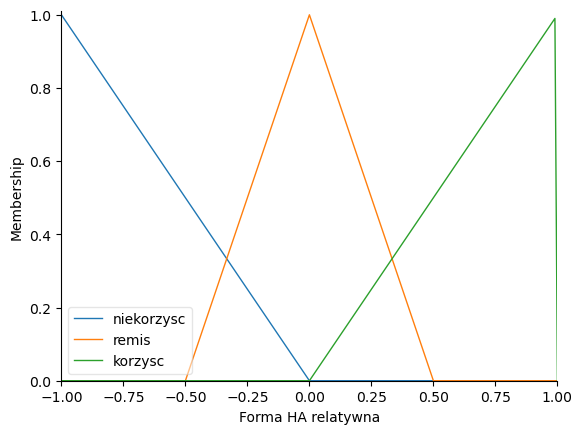

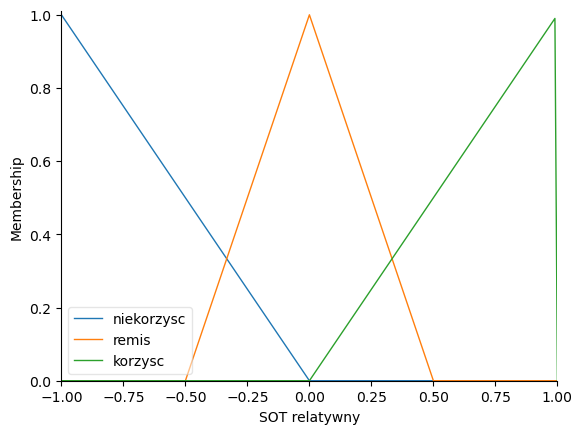

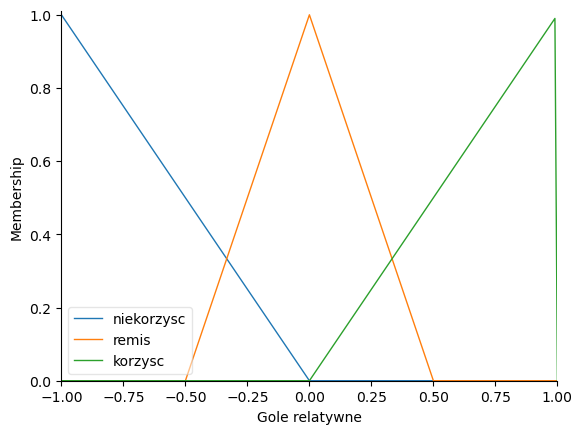

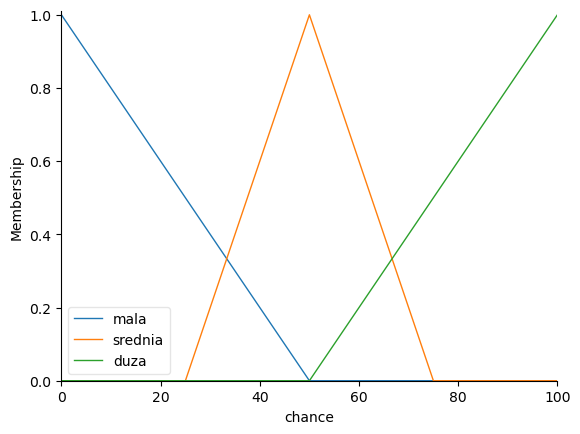

In [ ]:
forma_rel = ctrl.Antecedent(np.arange(-1, 1.01, 0.01), 'Forma HA relatywna')
sot_rel = ctrl.Antecedent(np.arange(-1, 1.01, 0.01), 'SOT relatywny')
gole_rel = ctrl.Antecedent(np.arange(-1, 1.01, 0.01), 'Gole relatywne')

chance = ctrl.Consequent(np.arange(0, 101, 1), 'chance')

for var in [forma_rel, sot_rel, gole_rel]:
    var['niekorzysc'] = fuzz.trimf(var.universe, [-1, -1, 0])
    var['remis'] = fuzz.trimf(var.universe, [-0.5, 0, 0.5])
    var['korzysc'] = fuzz.trimf(var.universe, [0, 1, 1])

chance['mala'] = fuzz.trimf(chance.universe, [0, 0, 50])
chance['srednia'] = fuzz.trimf(chance.universe, [25, 50, 75])
chance['duza'] = fuzz.trimf(chance.universe, [50, 100, 100])

forma_rel.view()
sot_rel.view()
gole_rel.view()

Przedstawione wykresy ilustrują definicje funkcji przynależności dla trzech zmiennych wejściowych modelu: "Forma HA relatywna", "SOT relatywny" oraz "Gole relatywne". Każda ze zmiennych przyjmuje wartości w przedziale od -1 do 1 i jest opisywana przez trzy trójkątne zbiory rozmyte: sytuację "niekorzystną", "remis" oraz "korzystną". Wizualizują one bazową strukturę wejść systemu logiki rozmytej, pokazując zakresy mapowania statystyk przed procesem wprowadzania konkretnych danych meczowych.

p:\Anaconda\envs\fuzzy\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


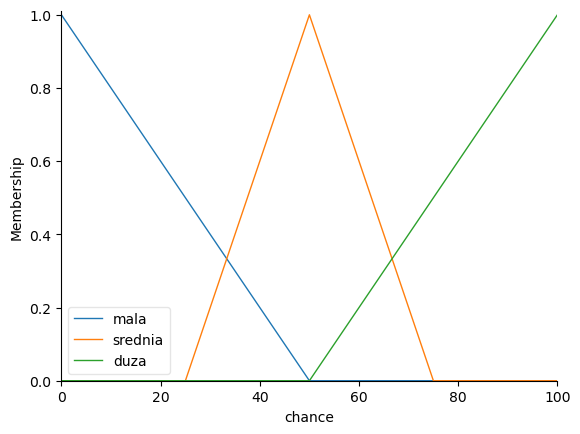

In [55]:
chance.view()

Wykres prezentuje definicje funkcji przynależności dla zmiennej wyjściowej "chance", reprezentującej prognozowane prawdopodobieństwo wygranej. Przestrzeń wyników w skali od 0 do 100 podzielono na trzy trójkątne zbiory rozmyte: szansę "małą", "średnią" oraz "dużą". Wizualizacja ukazuje bazową strukturę wyjścia systemu, na którą w kolejnych krokach mapowane są wyniki działania reguł logicznych przed końcowym wyostrzeniem.

3.5. Stworzenie reguł

Zbudowano kompletną bazę 27 reguł wnioskowania, pokrywającą każdą z możliwych kombinacji funkcji przynależności dla trzech zmiennych wejściowych ($3 \times 3 \times 3 = 27$). Baza reguł tłumaczy ludzkie rozumienie piłki nożnej na język matematyki – układ w którym zespół ma m.in. korzystną formę i przewagę w SOT skutkuje przydzieleniem "dużej" szansy na zwycięstwo, a nagromadzenie atrybutów niekorzystnych daje szansę "małą".

In [47]:
rule1  = ctrl.Rule(forma_rel['niekorzysc'] & sot_rel['niekorzysc'] & gole_rel['niekorzysc'], chance['mala'])
rule2  = ctrl.Rule(forma_rel['niekorzysc'] & sot_rel['niekorzysc'] & gole_rel['remis'], chance['mala'])
rule3  = ctrl.Rule(forma_rel['niekorzysc'] & sot_rel['niekorzysc'] & gole_rel['korzysc'], chance['mala'])

rule4  = ctrl.Rule(forma_rel['niekorzysc'] & sot_rel['remis'] & gole_rel['niekorzysc'], chance['mala'])
rule5  = ctrl.Rule(forma_rel['niekorzysc'] & sot_rel['remis'] & gole_rel['remis'], chance['mala'])
rule6  = ctrl.Rule(forma_rel['niekorzysc'] & sot_rel['remis'] & gole_rel['korzysc'], chance['srednia'])

rule7  = ctrl.Rule(forma_rel['niekorzysc'] & sot_rel['korzysc'] & gole_rel['niekorzysc'], chance['mala'])
rule8  = ctrl.Rule(forma_rel['niekorzysc'] & sot_rel['korzysc'] & gole_rel['remis'], chance['srednia'])
rule9  = ctrl.Rule(forma_rel['niekorzysc'] & sot_rel['korzysc'] & gole_rel['korzysc'], chance['srednia'])

rule10 = ctrl.Rule(forma_rel['remis'] & sot_rel['niekorzysc'] & gole_rel['niekorzysc'], chance['mala'])
rule11 = ctrl.Rule(forma_rel['remis'] & sot_rel['niekorzysc'] & gole_rel['remis'], chance['srednia'])
rule12 = ctrl.Rule(forma_rel['remis'] & sot_rel['niekorzysc'] & gole_rel['korzysc'], chance['srednia'])

rule13 = ctrl.Rule(forma_rel['remis'] & sot_rel['remis'] & gole_rel['niekorzysc'], chance['srednia'])
rule14 = ctrl.Rule(forma_rel['remis'] & sot_rel['remis'] & gole_rel['remis'], chance['srednia'])
rule15 = ctrl.Rule(forma_rel['remis'] & sot_rel['remis'] & gole_rel['korzysc'], chance['srednia'])

rule16 = ctrl.Rule(forma_rel['remis'] & sot_rel['korzysc'] & gole_rel['niekorzysc'], chance['mala'])
rule17 = ctrl.Rule(forma_rel['remis'] & sot_rel['korzysc'] & gole_rel['remis'], chance['srednia'])
rule18 = ctrl.Rule(forma_rel['remis'] & sot_rel['korzysc'] & gole_rel['korzysc'], chance['duza'])

rule19 = ctrl.Rule(forma_rel['korzysc'] & sot_rel['niekorzysc'] & gole_rel['niekorzysc'], chance['mala'])
rule20 = ctrl.Rule(forma_rel['korzysc'] & sot_rel['niekorzysc'] & gole_rel['remis'], chance['srednia'])
rule21 = ctrl.Rule(forma_rel['korzysc'] & sot_rel['niekorzysc'] & gole_rel['korzysc'], chance['duza'])

rule22 = ctrl.Rule(forma_rel['korzysc'] & sot_rel['remis'] & gole_rel['niekorzysc'], chance['srednia'])
rule23 = ctrl.Rule(forma_rel['korzysc'] & sot_rel['remis'] & gole_rel['remis'], chance['srednia'])
rule24 = ctrl.Rule(forma_rel['korzysc'] & sot_rel['remis'] & gole_rel['korzysc'], chance['duza'])

rule25 = ctrl.Rule(forma_rel['korzysc'] & sot_rel['korzysc'] & gole_rel['niekorzysc'], chance['srednia'])
rule26 = ctrl.Rule(forma_rel['korzysc'] & sot_rel['korzysc'] & gole_rel['remis'], chance['duza'])
rule27 = ctrl.Rule(forma_rel['korzysc'] & sot_rel['korzysc'] & gole_rel['korzysc'], chance['duza'])

3.6. Testowanie modelu

Reguły połączono w jeden system sterowania (`ControlSystem`). Następnie, iterując po wierszach przygotowanego wcześniej zbioru danych w pętli badającej poszczególne kolejki (`matchweek_df`), podawano zmienne do środowiska symulacji (`ControlSystemSimulation`). Wyniki estymacji prawdopodobieństwa wygranej przypisano do nowej kolumny `Szansa na wygraną (%)`.

In [48]:
chance_ctrl = ctrl.ControlSystem([
    rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, 
    rule10, rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18,
    rule19, rule20, rule21, rule22, rule23, rule24, rule25, rule26, rule27
])

chance_simulation = ctrl.ControlSystemSimulation(chance_ctrl)

results_chance = []

for idx, row in matchweek_df.iterrows():

    chance_simulation.input['Forma HA relatywna'] = row['Forma HA relatywna']
    chance_simulation.input['SOT relatywny'] = row['SOT relatywny']
    chance_simulation.input['Gole relatywne'] = row['Gole relatywne']

    chance_simulation.compute()
    results_chance.append(chance_simulation.output['chance'])

matchweek_df['Szansa na wygraną (%)'] = results_chance
matchweek_df.head(5)

,Kolejka,Drużyna,Przeciwnik,Status,Forma relatywna,Forma HA relatywna,SOT relatywny,Gole relatywne,Kursy relatywne,Wygrał,Pozycja,Pozycja przeciwnika,Pozycja relatywna,Kurs,Szansa na wygraną (%)
0,6,Wolves,Liverpool,Gospodarz,-0.7333,-0.4000,-0.2842,-0.6459,-0.6165,Liverpool,20,3,-0.8947,8.05,30.193798
1,6,Liverpool,Wolves,Gość,0.7333,0.4000,0.2842,0.6459,0.6165,Liverpool,3,20,0.8947,1.35,69.806202
2,6,Everton,Crystal Palace,Gospodarz,-0.1333,-0.0667,-0.0623,-0.1005,-0.0139,Everton,18,17,-0.0526,2.73,47.511631
3,6,Crystal Palace,Everton,Gość,0.1333,0.0667,0.0623,0.1005,0.0139,Everton,17,18,0.0526,2.63,52.488369
4,6,Chelsea,Brighton,Gospodarz,0.0667,-0.2000,-0.0897,0.0208,0.3448,Chelsea,6,8,0.1053,1.74,42.484277


Poniższy fragment kodu demonstruje praktyczne użycie zbudowanego systemu logiki rozmytej dla wybranego spotkania (Leicester City jako gospodarz przeciwko Manchesterowi United). Skrypt wyodrębnia dane meczowe z tabeli, wprowadza wartości trzech wskaźników relatywnych do symulatora, a następnie oblicza i wypisuje ostateczną prognozowaną szansę na zwycięstwo gospodarzy.

In [49]:
mecz = matchweek_df[(matchweek_df['Drużyna'] == 'Leicester') & (matchweek_df['Przeciwnik'] == 'Man United') & (matchweek_df['Status'] == 'Gospodarz')]
display(mecz)
row = mecz.iloc[0]

chance_simulation.input['Forma HA relatywna'] = row['Forma HA relatywna']
chance_simulation.input['SOT relatywny'] = row['SOT relatywny']
chance_simulation.input['Gole relatywne'] = row['Gole relatywne']

chance_simulation.compute()

print(f"Szansa na wygraną Leicester City: {chance_simulation.output['chance']:.2f}%")

,Kolejka,Drużyna,Przeciwnik,Status,Forma relatywna,Forma HA relatywna,SOT relatywny,Gole relatywne,Kursy relatywne,Wygrał,Pozycja,Pozycja przeciwnika,Pozycja relatywna,Kurs,Szansa na wygraną (%)
358,29,Leicester,Man United,Gospodarz,-0.3333,-0.3333,-0.1735,-0.1721,-0.3059,Man United,19,13,-0.3158,4.21,35.459768


Szansa na wygraną Leicester City: 35.46%


p:\Anaconda\envs\fuzzy\Lib\site-packages\skfuzzy\control\fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


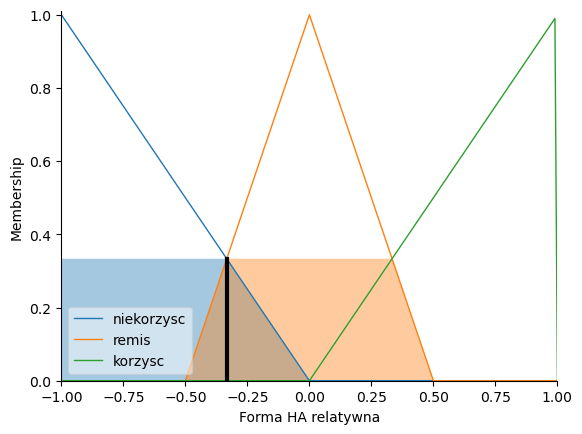

In [50]:
forma_rel.view(sim=chance_simulation)

Wykres wizualizuje proces rozmywania (fuzzaryzacji) zmiennej wejściowej "Forma HA relatywna", definiowanej przez trzy funkcje przynależności: *niekorzystną*, *remisową* i *korzystną*. Czarna pionowa linia wskazuje konkretną wartość dla pojedynczego meczu (około -0.33), która aktywuje zbiory "niekorzystna" oraz "remis" na poziomie bliskim 0.33. Zacieniowane obszary pod wykresami reprezentują wynik wnioskowania rozmytego (obcięte zbiory) dla tej konkretnej wartości, które w kolejnym etapie systemu zostaną zagregowane w celu wyostrzenia ostatecznego wyniku prawdopodobieństwa wygranej.

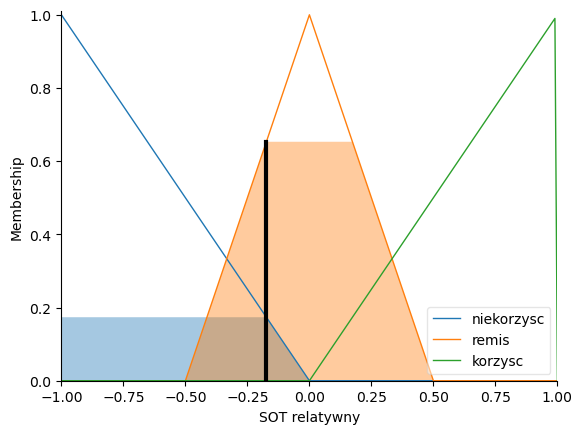

In [51]:
sot_rel.view(sim=chance_simulation)

Wykres ilustruje proces rozmywania (fuzzaryzacji) zmiennej wejściowej "SOT relatywny" dla analizowanego spotkania. Czarna pionowa linia wskazuje konkretną wartość wskaźnika (ok. -.18), która aktywuje zbiór rozmyty "remis" w stopniu wysokim oraz zbiór "niekorzystna" w stopniu niższym. Zacieniowane obszary reprezentują wynik tego wnioskowania, który zostanie zagregowany przez system reguł w celu obliczenia ostatecznej szansy na wygraną.

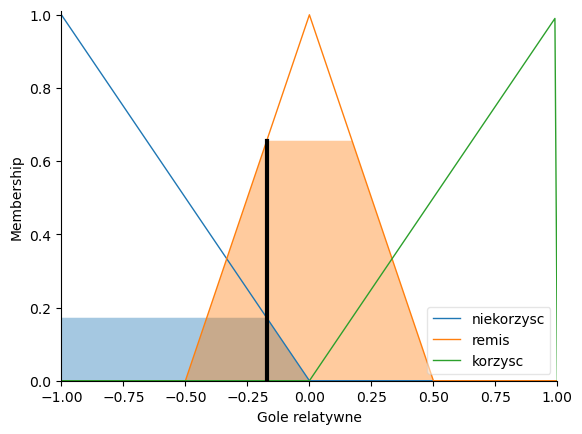

In [52]:
gole_rel.view(sim=chance_simulation)

Wykres ilustruje proces rozmywania (fuzzaryzacji) dla zmiennej wejściowej "Gole relatywne" w analizowanym spotkaniu. Czarna pionowa linia oznacza konkretną wartość tego wskaźnika (około -0.18), która aktywuje funkcję przynależności dla "remisu" w stosunkowo wysokim stopniu oraz dla sytuacji "niekorzystnej" w znacznie niższym. Zacieniowane pola pod wykresami reprezentują te aktywowane wartości rozmyte, które w kolejnym kroku zostaną zagregowane przez system reguł do obliczenia końcowego prawdopodobieństwa wygranej.

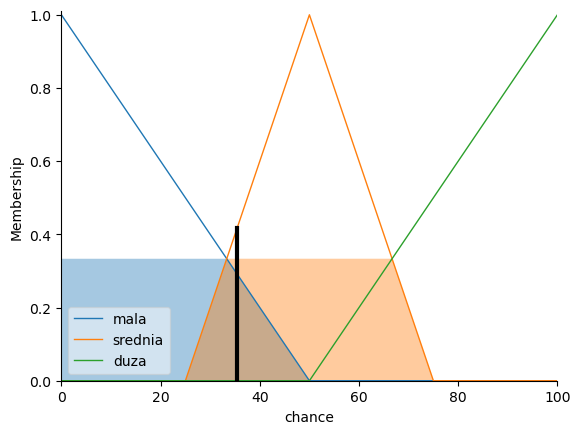

In [53]:
chance.view(sim=chance_simulation)

Wykres przedstawia końcowy etap działania systemu logiki rozmytej, czyli proces wyostrzania (defuzyfikacji) dla zmiennej wyjściowej określającej szansę na wygraną. Zacieniowane obszary obrazują zagregowane zbiory rozmyte dla szansy "małej" i "średniej", które zostały aktywowane przez system reguł na podstawie wprowadzonych statystyk meczowych. Czarna pionowa linia wskazuje ostateczną, liczbową wartość przewidywanej szansy na zwycięstwo analizowanej drużyny, która w tym przypadku wynosi około 35%.

3.7. Porównanie z przewidywaniami bukmacherów

W celu oceny skuteczności modelu w klasyfikacji wyników, sprawdzono, czy drużyna ze wskazaną szansą pow. 50% faktycznie wygrała dany mecz. Równolegle, z kursów bukmacherskich wyliczono rynkowe prawdopodobieństwo i na jego podstawie określono skuteczność bukmachera. Obliczono średnią poprawność prognoz dla obu metod oraz ich różnicę.

In [54]:
matchweek_df['Szansa bukmachera (%)'] = (1 / matchweek_df['Kurs']) * 100
matchweek_df['Poprawna prognoza fuzzy'] = (
    ((matchweek_df['Szansa na wygraną (%)'] >= 50) & (matchweek_df['Wygrał'] == matchweek_df['Drużyna'])) |
    ((matchweek_df['Szansa na wygraną (%)'] <= 50) & (matchweek_df['Wygrał'] == matchweek_df['Przeciwnik']))
)
 
matchweek_df['Poprawna prognoza bukmachera'] = (
    ((matchweek_df['Szansa bukmachera (%)'] >= 50) & (matchweek_df['Wygrał'] == matchweek_df['Drużyna'])) |
    ((matchweek_df['Szansa bukmachera (%)'] <= 50) & (matchweek_df['Wygrał'] == matchweek_df['Przeciwnik']))
)
 
acc_fuzzy = matchweek_df['Poprawna prognoza fuzzy'].mean() * 100
acc_buk   = matchweek_df['Poprawna prognoza bukmachera'].mean() * 100
roznica   = abs(acc_fuzzy - acc_buk)
 
print(f'Skuteczność fuzzy logic: {acc_fuzzy:.2f}%')
print(f'Skuteczność bukmachera: {acc_buk:.2f}%')
print(f'Różnica: {roznica:.2f}%')

Skuteczność fuzzy logic: 64.48%
Skuteczność bukmachera: 67.26%
Różnica: 2.78%


4. Podsumowanie

Wyniki eksperymentu potwierdziły wysoką użyteczność zastosowania systemów wnioskowania rozmytego w analizie danych sportowych. Stworzony od podstaw algorytm osiągnął skuteczność predykcji na poziomie **64.48%**. Dla porównania, skomplikowane rynkowe modele bukmacherskie, zasilane ogromną liczbą zmiennych, osiągnęły skuteczność na poziomie **67.26%**. Różnica rzędu 2.78 punktu procentowego stanowi doskonały rezultat. Wskazuje to, że agregacja jedynie trzech dobrze przemyślanych czynników wejściowych (forma Home/Away, SOT oraz bilans bramek) pozwala modelowi wykorzystującemu Fuzzy Logic podjąć decyzje o jakości bardzo zbliżonej do profesjonalnych szacunków opartych o "mądrość tłumu".